# Exercise 1

We first load a dataset and examine its dimensions.

In [1]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import math
import numpy as np

xy_data = np.load('Ex1_polyreg_data.npy')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/Ex1_polyreg_data.npy'

np.shape(xy_data)

(70, 2)

The matrix `xy_data` contains $70$ rows, each a data point of the form $(x_i,y_i)$ for $i=1, \ldots, 70$.

### 1a) Plot the data in a scatterplot.

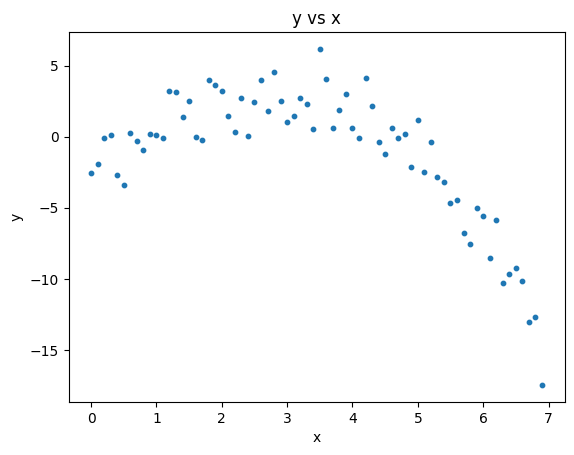

In [9]:
import matplotlib.pyplot as plt

plt.scatter(xy_data[:, 0], xy_data[:, 1], s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('y vs x')
plt.savefig('y_vs_x.pdf')
plt.show()

### 1b) Write a function `polyreg` to fit a polynomial of a given order to a dataset. 
The inputs to the function are a data matrix of dimension $N \times 2$,  and $k \geq 0$, the order of the polynomial.   The function should compute the coefficients of the polynomial $\beta_0 + \beta_1 x +  \ldots  +\beta_k x^{k}$ via least squares regression, and should return the coefficient vector, the fit, and the vector of residuals. 

If specified the degree $k$ is greater than or equal to $N$, then the function must fit an order $(N-1)$ polynomial and set the remaining coefficients to zero.

**NOTE**: You are *not* allowed to use the built-in function `np.polyfit`.

In [ ]:
def polyreg(data_matrix, k):
    import numpy as np
    
    # Extract x and y
    x = data_matrix[:, 0]
    y = data_matrix[:, 1]
    N = len(x)
    
    # If k >= N, fit polynomial of degree N-1
    if k >= N:
        k = N - 1
    
    # Build design matrix X 
    X = np.zeros((N, k + 1))
    for j in range(k + 1):
        X[:, j] = x**j
    
    # Compute beta using normal equations
    beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
    
    # Compute fitted values
    y_fit = X @ beta
    
    # Compute residuals
    residuals = y - y_fit
    
    return beta, y_fit, residuals

Use the tests below to check the outputs of the function you have written:

In [11]:
# Some tests to make sure your function is working correctly

xcol = np.arange(-1, 1.05, 0.1)
ycol = 2 - 7*xcol + 3*(xcol**2)  # We are generating data accoridng to y = 2 - 7x + 3x^2
test_matrix = np.transpose(np.vstack((xcol,ycol)))
test_matrix.shape

beta_test = polyreg(test_matrix, k=2)[0] 
assert((np.round(beta_test[0], 3) == 2) and (np.round(beta_test[1], 3) == -7) and (np.round(beta_test[2], 3) == 3))  
# We want to check that using the function with k=2 recovers the coefficients exactly

# Now check the zeroth order fit, i.e., the function gives the correct output with k=0
beta_test = polyreg(test_matrix, k=0)[0]
res_test = polyreg(test_matrix, k=0)[2] #the last output of the function gives the vector of residuals

assert(np.round(beta_test, 3) == 3.1)
assert(np.round(np.linalg.norm(res_test), 3) == 19.937)

### 1c) Use `polyreg` to fit polynomial models for the data in `xy_data` for $k=2,3,4$:

- Plot the fits for the three cases on the same plot together with the scatterplot of the data. The plots should be labelled and a legend included. 
- Compute and print the SSE and $R^2$ coefficient for each of the three cases.
- Which of the three models you would choose? Briefly justify your choice.

k = 2
  SSE = 172.1810
  MSE = 2.4597
  R^2 = 0.8876
k = 3
  SSE = 152.4058
  MSE = 2.1772
  R^2 = 0.9005
k = 4
  SSE = 151.2278
  MSE = 2.1604
  R^2 = 0.9013


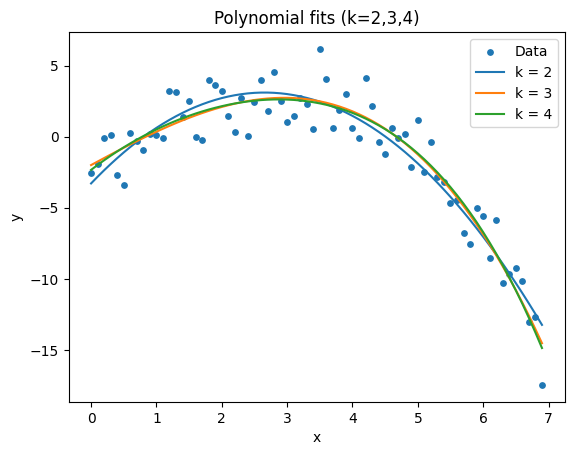

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Extract x and y
x = xy_data[:, 0]
y = xy_data[:, 1]
N = len(x)

# Total sum of squares (for R^2)
y_mean = np.mean(y)
SST = np.sum((y - y_mean)**2)

plt.scatter(x, y, s=15, label='Data')

for k in [2, 3, 4]:
    beta, y_fit, residuals = polyreg(xy_data, k)
    
    # Compute SSE
    SSE = np.sum(residuals**2)
    MSE = SSE / N
    # Compute R^2
    R2 = 1 - SSE/SST
    
    print(f"k = {k}")
    print(f"  SSE = {SSE:.4f}")
    print(f"  MSE = {MSE:.4f}")
    print(f"  R^2 = {R2:.4f}")
    
    # Compute smooth curve for plotting
    X_plot = np.zeros((len(x), k+1))
    for j in range(k+1):
        X_plot[:, j] = x**j
        
    y_plot = X_plot @ beta
    
    plt.plot(x, y_plot, label=f'k = {k}')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Polynomial fits (k=2,3,4)')
plt.show()

 #### State which model you choose and briefly justify your choice.
 
 
I would choose k = 3. The MSE decreases substantially from k = 2 to k = 3, indicating that the cubic term meaningfully improves the fit. However, the improvement from k = 3 to k = 4 is negligible, suggesting diminishing returns from increasing model complexity. k = 3 provides a good balance between model accuracy and generalizability.

### 1d)  For the model you have chosen in the previous part (either $k=2/3/4)$:

- Plot the residuals in a scatter plot. 
- Plot a histogram of the residuals along with a Gaussian pdf with zero mean and the same standard deviation as the residuals.

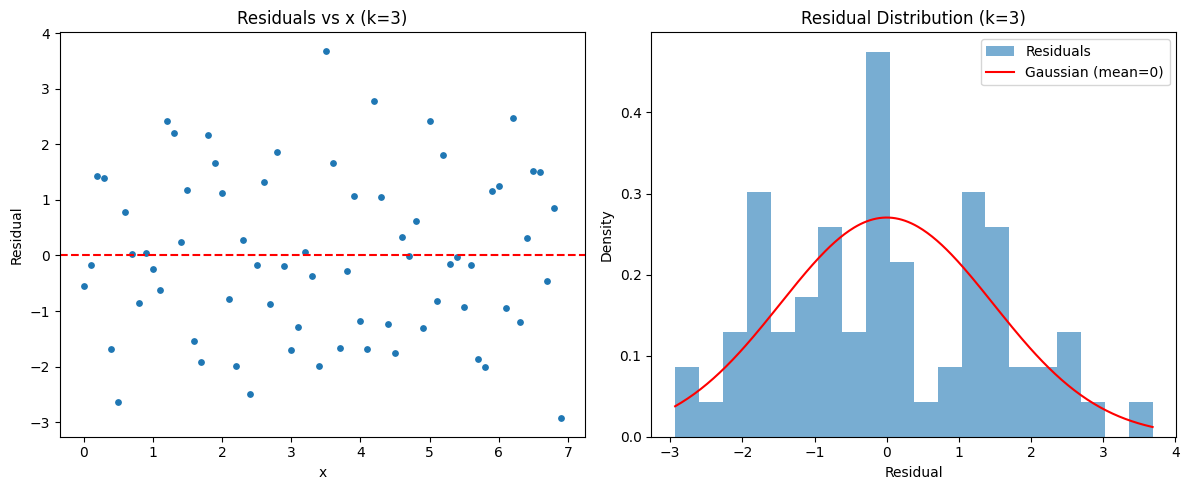

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Fit k = 3 model
beta, y_fit, residuals = polyreg(xy_data, 3)

x = xy_data[:, 0]

# ---- Residual scatter plot ----
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.scatter(x, residuals, s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('x')
plt.ylabel('Residual')
plt.title('Residuals vs x (k=3)')

# ---- Histogram + Gaussian overlay ----
plt.subplot(122)

# Histogram (density=True so it integrates to 1)
plt.hist(residuals, bins=20, density=True, alpha=0.6, label='Residuals')

# Gaussian with mean 0 and same std
sigma = np.std(residuals)
x_vals = np.linspace(min(residuals), max(residuals), 300)
gaussian_pdf = norm.pdf(x_vals, 0, sigma)

plt.plot(x_vals, gaussian_pdf, 'r', label='Gaussian (mean=0)')
plt.xlabel('Residual')
plt.ylabel('Density')
plt.title('Residual Distribution (k=3)')
plt.legend()

plt.tight_layout()
plt.show()